In [16]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [17]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons",
    "TrueNElec", "TrueNProt", "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial",
    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len", "reco_e",
    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid", "RecoElectron_conversion_dist",
    "pi0_radlen1", "pi0_radlen2", "pi0_score", "nonpi0_score", "bkg_score",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",
]

In [18]:
#RUN = ["1","2","3","4b","4c","4d","5"]
RUN = ["3"]

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=True,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=True,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3
Updating keep_columns with truth-filtering variables: {'ccnc', 'nu_pdg'}


In [19]:
run_combo = "Run"
for run in RUN:
    run_combo += run

In [20]:
from microfit import selections as sel

selection = "None"
preselection = "OneP_new"
query = f"{sel.preselection_categories[preselection]['query']}" #" and {sel.selection_categories[selection]['query']}"
#sel_title = f"{sel.selection_categories[selection]['title']}"

all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])
sel_mc = all_mc.query(query, engine='python')
is_sig = sel_mc['category_1e1p'] == 12
sel_sig = sel_mc.loc[is_sig]
sel_bkg = sel_mc.loc[~is_sig]

In [36]:
from mpl_toolkits.mplot3d import Axes3D

def plot3Dhist(df, xvar, yvar, xlabel, ylabel, title, color, bins=20, range=[[0,1],[0,1]]):
    
    x = df[xvar]
    y = df[yvar]
    
    # Create a 2D histogram
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins, weights=df["weights"], range=range)
    
    # Create coordinates for the bars
    xpos, ypos = np.meshgrid(xedges[:-1] + np.diff(xedges) / 2,
                             yedges[:-1] + np.diff(yedges) / 2, indexing="ij")
    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = np.zeros_like(xpos)  # Start at z=0

    # The heights of the bars
    values = hist.ravel()

    # Dimensions of the bars
    dx = dy = np.diff(xedges)[0]  # Bin width
    dz = values  # Height is the histogram value

    # Create the 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the histogram bars
    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True, color=color, alpha=0.7)

    # Add labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel('Events')
    plt.title(title)
    
    fig.canvas.draw() # need to render the plot to be able to save it


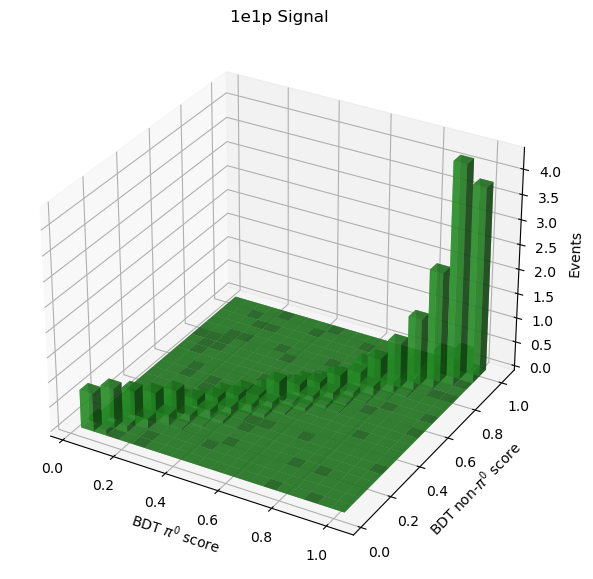

In [37]:
# Selected signal - pi0 & non-pi0

plot3Dhist(sel_sig, "pi0_score", "nonpi0_score", "BDT $\\pi^{0}$ score", "BDT non-$\\pi^{0}$ score", "1e1p Signal", "tab:green")
plt.savefig(f'plots/reco_study/bdt_scores/3D_sig_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/3D_sig_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

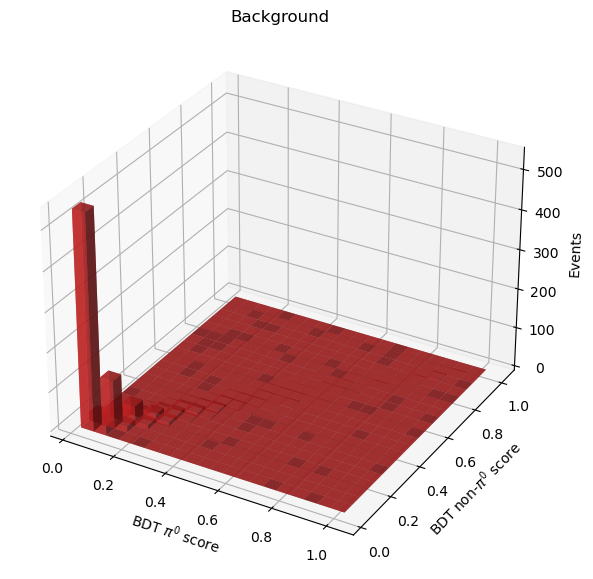

<Figure size 640x480 with 0 Axes>

In [38]:
# Selected background - pi0 & non-pi0

plot3Dhist(sel_bkg, "pi0_score", "nonpi0_score", "BDT $\\pi^{0}$ score", "BDT non-$\\pi^{0}$ score", "Background", "tab:red")
plt.savefig(f'plots/reco_study/bdt_scores/3D_bkg_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/3D_bkg_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected signal - pi0 & 0p

plot3Dhist(sel_sig, "pi0_score", "bkg_score", "BDT $\\pi^{0}$ score", "1e0p BDT score", "1e1p Signal", "tab:green")
plt.savefig(f'plots/reco_study/bdt_scores/3D_sig_pi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/3D_sig_pi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected background - pi0 & 0p

plot3Dhist(sel_bkg, "pi0_score", "bkg_score", "BDT $\\pi^{0}$ score", "1e0p BDT score", "Background", "tab:red")
plt.savefig(f'plots/reco_study/bdt_scores/3D_bkg_pi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/3D_bkg_pi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected signal - nonpi0 & 0p

plot3Dhist(sel_sig, "nonpi0_score", "bkg_score", "BDT non-$\\pi^{0}$ score", "1e0p BDT score", "1e1p Signal", "tab:green")
plt.savefig(f'plots/reco_study/bdt_scores/3D_sig_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/3D_sig_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected background - nonpi0 & 0p

plot3Dhist(sel_bkg, "nonpi0_score", "bkg_score", "BDT non-$\\pi^{0}$ score", "1e0p BDT score", "Background", "tab:red")
plt.savefig(f'plots/reco_study/bdt_scores/3D_bkg_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/3D_bkg_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

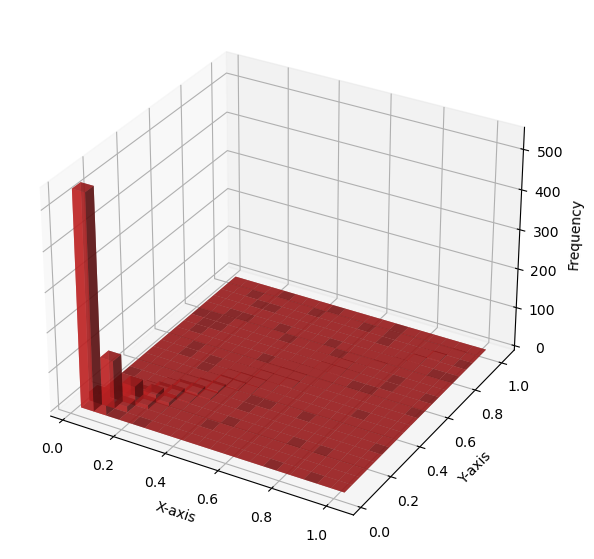

In [14]:
from mpl_toolkits.mplot3d import Axes3D

x = sel_bkg["pi0_score"]
y = sel_bkg["nonpi0_score"]

# Define the number of bins
bins = 20

# Create a 2D histogram
hist, xedges, yedges = np.histogram2d(x, y, bins=bins, weights=sel_bkg["weights"], range=[[0,1],[0,1]])

# Create coordinates for the bars
xpos, ypos = np.meshgrid(xedges[:-1] + np.diff(xedges) / 2,
                         yedges[:-1] + np.diff(yedges) / 2, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)  # Start at z=0

# The heights of the bars
values = hist.ravel()

# Dimensions of the bars
dx = dy = np.diff(xedges)[0]  # Bin width
dz = values  # Height is the histogram value

# Create the 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the histogram bars
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True, color='tab:red', alpha=0.7)

# Add labels
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Frequency')

plt.show()
